# Viral sequence analysis from czid data
This notebook was created to analyze [CZID](https://czid.org) data from the same samples that will be analyzed through our shell scripts. The main idea behind this is to corroborate the results given by both methods and determine the viability of the designed pipeline. 

## Libraries.

In [1]:
# Libraries for data manipulation and visualization

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




## Data load.
All sample information was downloaded.

In [2]:
base_path = Path.cwd().parents[1]

file_paths = {
    "PM3183": base_path / 'docs/czid_sequence_reports/PM3183_S6_923339_taxon_report.csv',
    "PM3051": base_path / 'docs/czid_sequence_reports/PM3051_S4_923337_taxon_report.csv',
    "PM3153": base_path / 'docs/czid_sequence_reports/PM3153_S5_923338_taxon_report.csv',
    "PM2622": base_path / 'docs/czid_sequence_reports/PM2622_S32_923335_taxon_report.csv',
    "PM2616": base_path / 'docs/czid_sequence_reports/PM2616_S22_923334_taxon_report.csv',
    "PM2601": base_path / 'docs/czid_sequence_reports/PM2601_S14_923333_taxon_report.csv',
    "PM2577": base_path / 'docs/czid_sequence_reports/PM2577_S13_923332_taxon_report.csv',
    "PM2539": base_path / 'docs/czid_sequence_reports/PM2539_S23_923331_taxon_report.csv',
    "PM2528": base_path / 'docs/czid_sequence_reports/PM2528_S2_923330_taxon_report.csv',
    "PM2524": base_path / 'docs/czid_sequence_reports/PM2524_S24_923329_taxon_report.csv',
    "PM2494": base_path / 'docs/czid_sequence_reports/PM2494_S26_923327_taxon_report.csv',
    "PM2469": base_path / 'docs/czid_sequence_reports/PM2469_S1_923325_taxon_report.csv',
}

samples = list(file_paths.keys())


    

## Dataframe modification.

In [3]:
# Dataframe modification and concatenation.

df_samples= []

for i in samples:
    # File read for each sample.
    file = file_paths[i]
    print(f"Sample: {i}")
    df=pd.read_csv(file)

    # Since the taxon category column is of our interest, we can filter every dataframe by the value of 'viruses' in the taxon category column to keep only the rows that have this value. 
    row_del = df['category'] == 'viruses' # If the taxId column has the value 'viruses' then we keep that row, otherwise we delete it.
    df = df[row_del].copy()

    # Add sample name to the dataframe.
    df['sample_name'] = i
    df_samples.append(df)


# Dataframe concatenation.
df_samples = pd.concat(df_samples, ignore_index=True)

display(df_samples)

Sample: PM3183
Sample: PM3051
Sample: PM3153
Sample: PM2622
Sample: PM2616
Sample: PM2601
Sample: PM2577
Sample: PM2539
Sample: PM2528
Sample: PM2524
Sample: PM2494
Sample: PM2469


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,agg_score,max_z_score,nt_z_score,...,nr_percent_identity,nr_alignment_length,nr_e_value,nr_bg_mean,nr_bg_stdev,nr_bg_mean_mass_normalized,nr_bg_stdev_mass_normalized,species_tax_ids,known_pathogen,sample_name
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,72.0000,25.0000,10^-5.79588,NaN,NaN,NaN,NaN,[2844040],0,PM3183
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,72.0000,25.0000,10^-5.79588,NaN,NaN,NaN,NaN,NaN,0,PM3183
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,83.6500,24.5000,10^-5.18245,NaN,NaN,NaN,NaN,[2980617],0,PM3183
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,83.6500,24.5000,10^-5.18245,NaN,NaN,NaN,NaN,NaN,0,PM3183
4,1307798,2,1307798,Negevirus,NaN,viruses,False,NaN,NaN,NaN,...,97.2333,24.0000,10^-6.41519,NaN,NaN,NaN,NaN,[2651953],0,PM3183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,PM2469
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,85.7571,24.1429,10^-4.54861,NaN,NaN,NaN,NaN,[2689361],0,PM2469
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,85.7571,24.1429,10^-4.54861,NaN,NaN,NaN,NaN,NaN,0,PM2469
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,100.0000,24.0000,10^-6.50585,NaN,NaN,NaN,NaN,[2789442],0,PM2469


In [4]:
# Dataframe cleaning and manipulation.
df_samples = df_samples.drop(columns= ['agg_score',	'max_z_score',	'nt_z_score', 'nt_bg_mean',	'nt_bg_stdev',	
                                       'nt_bg_mean_mass_normalized',	'nt_bg_stdev_mass_normalized',	'nr_z_score', 
                                       'nr_bg_mean',	'nr_bg_stdev',	'nr_bg_mean_mass_normalized',	'nr_bg_stdev_mass_normalized'])
display(df_samples)



,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,nr_rpm,nr_count,nr_contigs,nr_contig_r,nr_percent_identity,nr_alignment_length,nr_e_value,species_tax_ids,known_pathogen,sample_name
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,0.119115,1.0,NaN,NaN,72.0000,25.0000,10^-5.79588,[2844040],0,PM3183
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,0.119115,1.0,NaN,NaN,72.0000,25.0000,10^-5.79588,NaN,0,PM3183
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,0.238229,2.0,NaN,NaN,83.6500,24.5000,10^-5.18245,[2980617],0,PM3183
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,0.238229,2.0,NaN,NaN,83.6500,24.5000,10^-5.18245,NaN,0,PM3183
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,0.357344,3.0,NaN,NaN,97.2333,24.0000,10^-6.41519,[2651953],0,PM3183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,21.134359,184.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,PM2469
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,0.804025,7.0,NaN,NaN,85.7571,24.1429,10^-4.54861,[2689361],0,PM2469
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,0.804025,7.0,NaN,NaN,85.7571,24.1429,10^-4.54861,NaN,0,PM2469
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,0.114861,1.0,NaN,NaN,100.0000,24.0000,10^-6.50585,[2789442],0,PM2469


In [5]:

# Metadata by sample. This includes sample name, locality, mosquito species, ecological classification
df_metadata = pd.read_csv(base_path / 'docs/czid_sequence_reports/sample_overviews.csv')

# Metadata cleaning and manipulation.

# Sample name modification to match sample names in the sequence report dataframe.
df_metadata["sample_name"] = df_metadata["sample_name"].str.replace(r"_S\d{1,2}", "", regex=True)

# Variable renaming.
df_metadata["state"] = df_metadata["collection_location"].str.strip()

# Column dropping.
df_metadata = df_metadata.drop(columns= ['upload_date', 'notes', 'insert_size_median',	'insert_size_mode',	'insert_size_median_absolute_deviation',	
                                         'insert_size_min',	'insert_size_max',	'insert_size_mean',	'insert_size_standard_deviation',	'insert_size_read_pairs', 'collection_location'])


# Sampling site
site = {
    "PM2469": "Nuevo_Conhuas",
    "PM2486": "Calkini",
    "PM2494": "Calkini",
    "PM2497": "Calkini",
    "PM2524": "Nuevo_Conhuas",
    "PM2528": "Nuevo_Conhuas",
    "PM2539": "Merida",
    "PM2577": "Nuevo_Conhuas",
    "PM2601": "San_Simon",
    "PM2616": "San_Simon",
    "PM2622": "San_Simon",
    "PM3050": "Palizada",
    "PM3051": "Palizada",
    "PM3153": "Caobas",
    "PM3183": "Caobas"
}

df_metadata["site"] = df_metadata["sample_name"].map(site)

# Sample ecological classification based on the locality of collection.
habitat = {
    "PM2469": "conservado",
    "PM2486": "diversificado",
    "PM2494": "diversificado",
    "PM2497": "diversificado",
    "PM2524": "conservado",
    "PM2528": "conservado",
    "PM2539": "urbano",
    "PM2577": "conservado",
    "PM2601": "conservado",
    "PM2616": "conservado",
    "PM2622": "conservado",
    "PM3050": "rural",
    "PM3051": "rural",
    "PM3153": "diversificado",
    "PM3183": "diversificado"
}

df_metadata["habitat"] = df_metadata["sample_name"].map(habitat)

# Mosquito species by sample
species = {
    "PM2469": "aedes_serratus",
    "PM2486": "aedes_taeniorhynchus",
    "PM2494": "aedes_taeniorhynchus",
    "PM2497": "aedes_taeniorhynchus",
    "PM2524": "aedes_taeniorhynchus",
    "PM2528": "aedes_serratus",
    "PM2539": "aedes_taeniorhynchus",
    "PM2577": "aedes_taeniorhynchus",
    "PM2601": "aedes_taeniorhynchus",
    "PM2616": "aedes_taeniorhynchus",
    "PM2622": "aedes_taeniorhynchus",
    "PM3050": "aedes_serratus",
    "PM3051": "aedes_serratus",
    "PM3153": "aedes_serratus",
    "PM3183": "aedes_serratus"
}

df_metadata["species"] = df_metadata["sample_name"].map(species)

display(df_metadata)

''

,sample_name,uploader,overall_job_status,runtime_seconds,total_reads,passed_filters,passed_filters_percent,host_organism,total_ercc_reads,subsampled_fraction,...,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species
0,PM2469,Jorge Alberto Castro Rodríguez,COMPLETE,2696,8706270,829594,9.529,Mosquito,68.0,1.000000,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1,PM2486,Jorge Alberto Castro Rodríguez,COMPLETE,9848,50503296,2387038,4.726,Mosquito,1474.0,0.192452,...,12471436,10562598,Whole Body,RNA,2024-01-01,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
2,PM2494,Jorge Alberto Castro Rodríguez,COMPLETE,10911,58137502,2539988,4.369,Mosquito,1466.0,0.229556,...,11270008,8684188,Whole Body,RNA,2024-01-01,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
3,PM2497,Jorge Alberto Castro Rodríguez,COMPLETE,15493,85303732,2316318,2.715,Mosquito,1676.0,0.145220,...,30008832,13753536,Whole Body,RNA,2024-01-01,No,Campeche,Calkini,diversificado,aedes_taeniorhynchus
4,PM2524,Jorge Alberto Castro Rodríguez,COMPLETE,13575,86905432,2482244,2.856,Mosquito,1814.0,0.153837,...,17121448,12971102,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_taeniorhynchus
5,PM2528,Jorge Alberto Castro Rodríguez,COMPLETE,1863,8930878,79774,0.893,Mosquito,NaN,1.000000,...,4138704,70994,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
6,PM2539,Jorge Alberto Castro Rodríguez,COMPLETE,10665,63853214,2912528,4.561,Mosquito,NaN,0.302195,...,11652590,6704294,Whole Body,RNA,2024-01-01,No,Yucatán,Merida,urbano,aedes_taeniorhynchus
7,PM2577,Jorge Alberto Castro Rodríguez,COMPLETE,19809,150000000,2939542,1.960,Mosquito,1546.0,0.220693,...,26217300,8980510,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_taeniorhynchus
8,PM2601,Jorge Alberto Castro Rodríguez,COMPLETE,14353,88653284,3530880,3.983,Mosquito,320.0,0.945653,...,26932094,2100916,Whole Body,RNA,2024-01-01,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus
9,PM2616,Jorge Alberto Castro Rodríguez,COMPLETE,9984,47621670,2953128,6.201,Mosquito,1746.0,0.522178,...,5995012,3863030,Whole Body,RNA,2024-01-01,No,Yucatán,San_Simon,conservado,aedes_taeniorhynchus


''

In [6]:
# Dataframe merging.
df_final = df_samples.merge(
    df_metadata,
    on="sample_name",
    how="left"
)

print(df_final.columns.tolist())
display(df_final)

['tax_id', 'tax_level', 'genus_tax_id', 'name', 'common_name', 'category', 'is_phage', 'nt_rpm', 'nt_count', 'nt_contigs', 'nt_contig_r', 'nt_percent_identity', 'nt_alignment_length', 'nt_e_value', 'nr_rpm', 'nr_count', 'nr_contigs', 'nr_contig_r', 'nr_percent_identity', 'nr_alignment_length', 'nr_e_value', 'species_tax_ids', 'known_pathogen', 'sample_name', 'uploader', 'overall_job_status', 'runtime_seconds', 'total_reads', 'passed_filters', 'passed_filters_percent', 'host_organism', 'total_ercc_reads', 'subsampled_fraction', 'quality_control', 'compression_ratio', 'reads_after_bowtie2_ercc_filtered', 'reads_after_fastp', 'reads_after_bowtie2_host_filtered', 'reads_after_hisat2_host_filtered', 'reads_after_czid_dedup', 'sample_type', 'nucleotide_type', 'collection_date', 'water_control', 'state', 'site', 'habitat', 'species']


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,3931426,57760,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,21.134359,184.0,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,1650712,667202,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus


In [7]:
import taxopy

db = taxopy.TaxDb()

# Create empty lists to store results
lineage_list = []
family_list = []

# Iterate through each tax_id
for taxid in df_final['tax_id']:
    # Try to get taxonomy for ALL taxids (including negatives)
    try:
        tax = taxopy.Taxon(taxid, db)
        # Get the rank dictionary
        lineage_dict = tax.rank_name_dictionary
        # Extract family if it exists
        family = lineage_dict.get('family')
        
        # If no family found, mark as Unclassified
        if family is None:
            family = 'Unclassified'
        
        lineage_list.append(lineage_dict)
        family_list.append(family)
        
    except Exception as e:
        # If taxopy fails completely
        print(f"Error with taxid {taxid}: {e}")
        # Create a basic lineage dict with Unclassified
        lineage_list.append({
            'family': 'Unclassified',
            'note': f'Could not retrieve from NCBI: {str(e)}'
        })
        family_list.append('Unclassified')

# Add results to dataframe
df_final['lineage'] = lineage_list
df_final['family'] = family_list

print(df_final[['tax_id', 'family']].head(10))

Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200249310: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011006: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011012: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200186665: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -202169529: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200010860: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011006: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200186665: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200

In [ ]:
display(df_final)
df_final.to_csv(base_path / 'docs/czid_sequence_reports/df_final_overview.csv', index=False)

,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,sample_type,nucleotide_type,collection_date,water_control,state,site,habitat,species,family,lineage
0,2842620,2,2842620,Culicidavirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus,Chuviridae,"{'genus': 'Culicidavirus', 'family': 'Chuvirid..."
1,2844040,1,2842620,Culicidavirus quitotaense,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus,Chuviridae,"{'species': 'Culicidavirus quitotaense', 'genu..."
2,1884455,2,1884455,Anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus,Xinmoviridae,"{'genus': 'Anphevirus', 'family': 'Xinmovirida..."
3,2980617,1,1884455,Joensuu anphevirus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus,Xinmoviridae,"{'species': 'Joensuu anphevirus', 'genus': 'An..."
4,1307798,2,1307798,Negevirus,NaN,viruses,False,0.238229,2.0,NaN,...,Whole Body,RNA,2024-01-01,No,Quintana Roo,Caobas,diversificado,aedes_serratus,Unclassified,"{'genus': 'Negevirus', 'clade': 'unclassified ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2952019,1,-200012058,XiangYun picorna-like virus 2,NaN,viruses,False,21.134359,184.0,NaN,...,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus,Picornaviridae,"{'species': 'XiangYun picorna-like virus 2', '..."
1273,-200186665,2,-200186665,non-genus-specific reads in family Metaviridae,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus,Unclassified,"{'family': 'Unclassified', 'note': 'Could not ..."
1274,2689361,1,-200186665,Chibugado virus,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus,Metaviridae,"{'species': 'Chibugado virus', 'family': 'Meta..."
1275,-200232795,2,-200232795,non-genus-specific reads in family Dicistrovir...,NaN,viruses,False,NaN,NaN,NaN,...,Whole Body,RNA,2024-01-01,No,Campeche,Nuevo_Conhuas,conservado,aedes_serratus,Unclassified,"{'family': 'Unclassified', 'note': 'Could not ..."


## Data Visualization

### Heatmap of the most abundant viral taxa across samples.

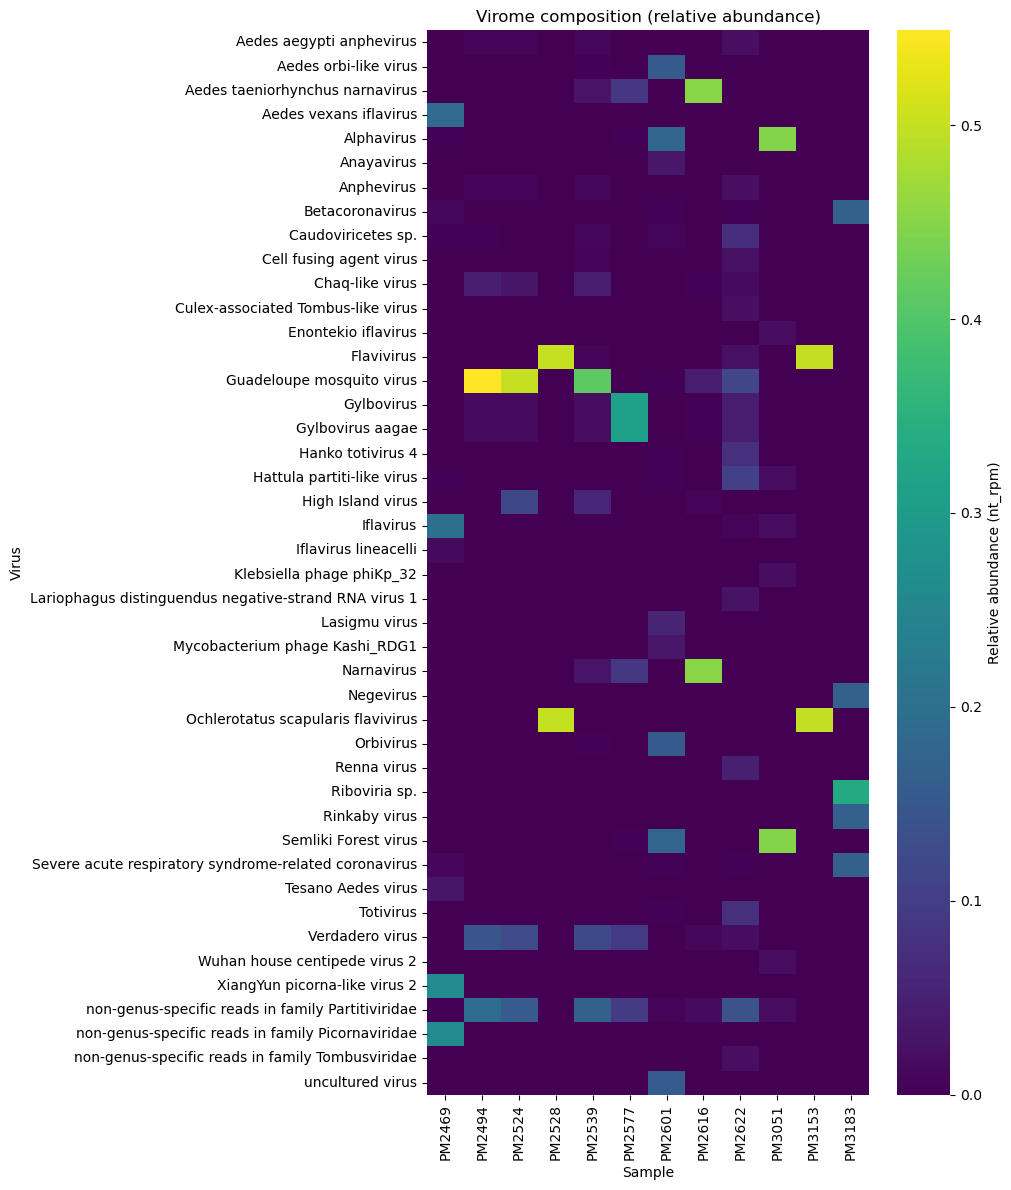

In [32]:
# Data visualization.

pivot = df_final.pivot_table(
    index="name",
    columns="sample_name", 
    values="nt_rpm",
    aggfunc="sum",
    fill_value=0
)
pivot_rel = pivot.div(pivot.sum(axis=0), axis=1)

# Low informative taxa filtering. We filter out taxa that have a relative abundance of less than 1% in all samples.
pivot_filt = pivot_rel[pivot_rel.max(axis=1) > 0.01]  # >1%

plt.figure(figsize=(10, 12))

sns.heatmap(
    pivot_filt,
    cmap="viridis",
    cbar_kws={"label": "Relative abundance (nt_rpm)"}
)

plt.title("Virome composition (relative abundance)")
plt.xlabel("Sample")
plt.ylabel("Virus")
plt.tight_layout()
plt.show()

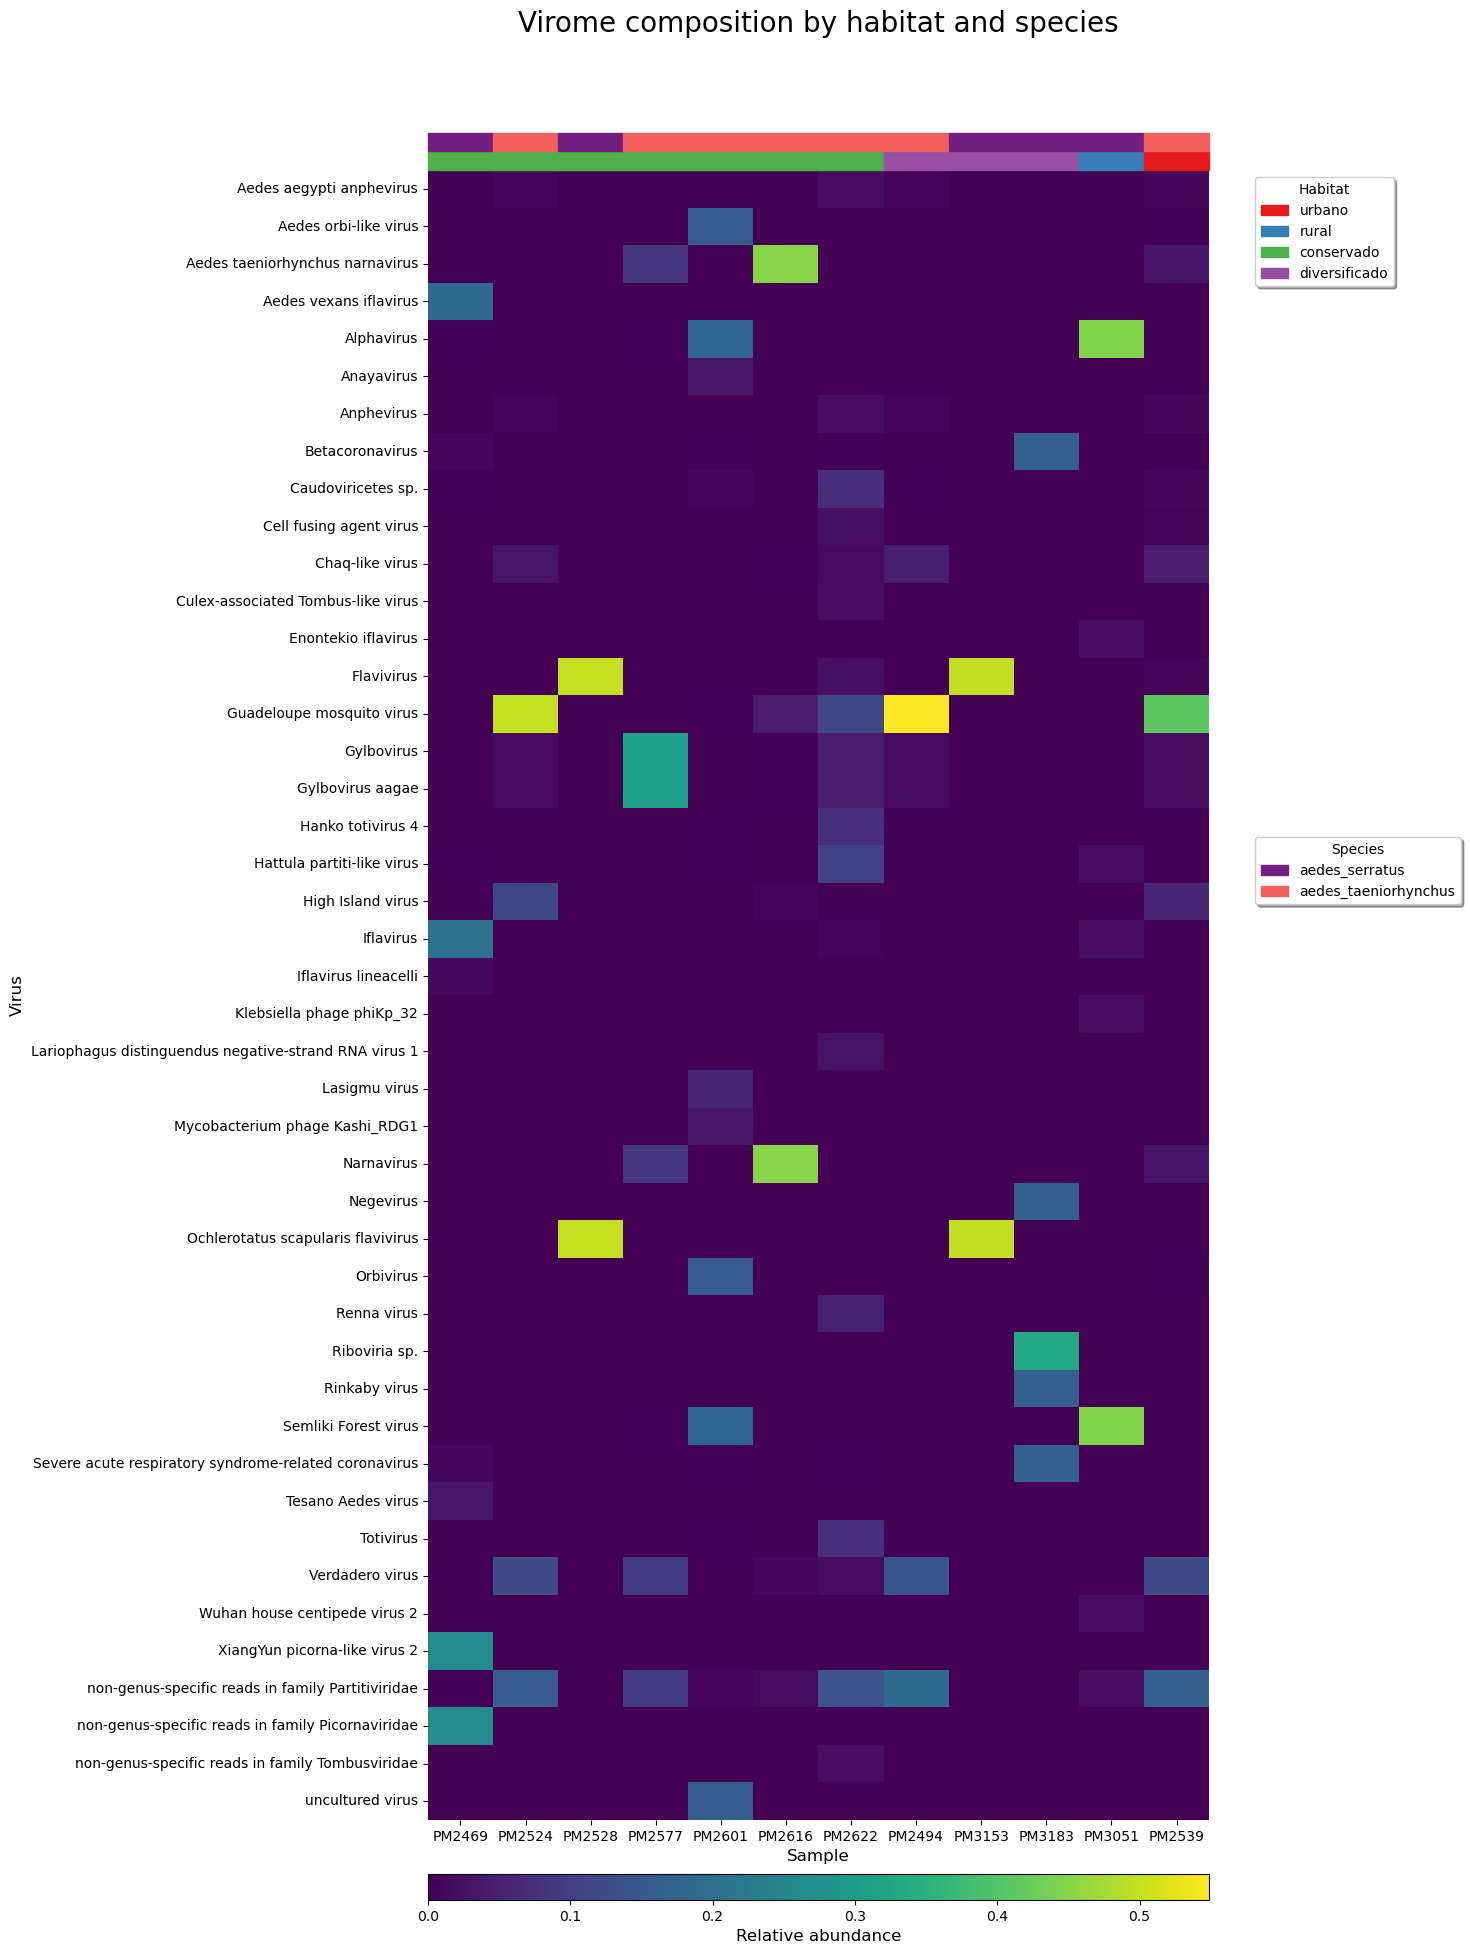

In [33]:
order = df_metadata.sort_values(["habitat", "site"])["sample_name"]

# Only those samples that remain after filtering
order = [s for s in order if s in pivot_filt.columns]

pivot_ordered = pivot_filt[order]

# Index metadata
meta = df_metadata.set_index("sample_name")

# Colors mapping
habitat_colors = meta.loc[order, "habitat"].map({
    "urbano": "#e41a1c",
    "rural": "#377eb8",
    "conservado": "#4daf4a",
    "diversificado": "#984ea3"
})

species_unique = meta["species"].unique()
palette = sns.color_palette("magma", len(species_unique))
species_color_dict = dict(zip(species_unique, palette))
species_colors = meta.loc[order, "species"].map(species_color_dict)

# Subplots for title and heatmap
fig, (ax_title, ax_heatmap) = plt.subplots(
    2, 1, 
    figsize=(15, 20), 
    gridspec_kw={'height_ratios': [0.5, 10]}
)

# Subplot for title hidden 
ax_title.axis('off')
ax_title.set_title("Virome composition by habitat and species", fontsize=20, pad=1)

# Create heatmap without colorbar first
ax = sns.heatmap(
    pivot_ordered,
    cmap="viridis",
    cbar=False,  # Disable default colorbar
    ax=ax_heatmap
)

# Add colorbar at the bottom
cbar = fig.colorbar(ax.collections[0], ax=ax, orientation='horizontal', 
                    pad=0.03, fraction=0.05, aspect=30)
cbar.set_label("Relative abundance", fontsize=12)

# Habitat color above heatmap
for i, color in enumerate(habitat_colors):
    ax.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=color, transform=ax.transData, clip_on=False)
    )

# Species color above habitat
for i, color in enumerate(species_colors):
    ax.add_patch(
        plt.Rectangle((i, -1.0), 1, 0.5, color=color, transform=ax.transData, clip_on=False)
    )

# Habitat Leyend
hab_legend = [
    mpatches.Patch(color=color, label=hab)
    for hab, color in {
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"
    }.items()
]

# Species Leyend
sp_legend = [
    mpatches.Patch(color=color, label=sp)
    for sp, color in species_color_dict.items()
]

# Add both legends on the right side without overlap
legend1 = ax.legend(
    handles=hab_legend,
    title="Habitat",
    bbox_to_anchor=(1.05, 1.0),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)

legend2 = ax.legend(
    handles=sp_legend,
    title="Species",
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
)

ax.add_artist(legend1)

# Etiquetas de ejes
ax.set_xlabel("Sample", fontsize=12)
ax.set_ylabel("Virus", fontsize=12)

plt.tight_layout()
plt.show()

### PCA Analysis.

PC1 explains: 25.85%
PC2 explains: 15.81%
Total explained: 41.66%


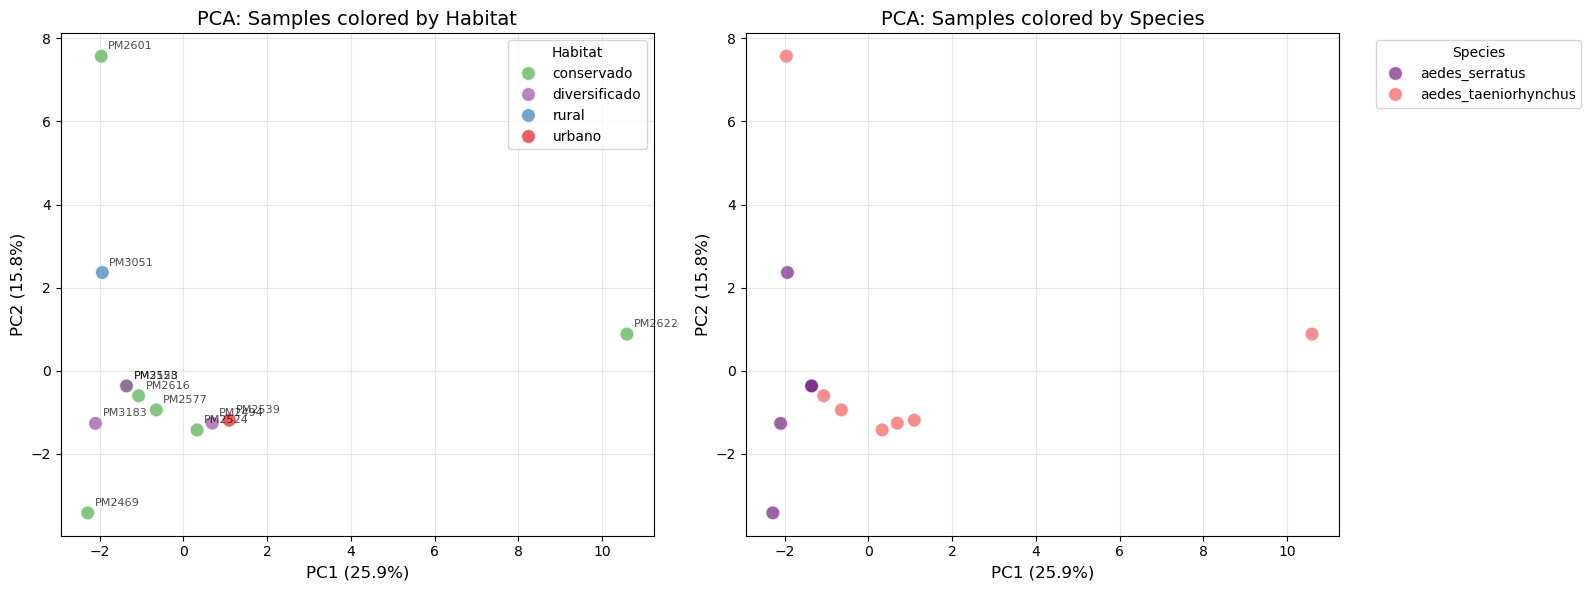


Explained variance ratio:
PC1: 25.85% (cumulative: 25.85%)
PC2: 15.81% (cumulative: 41.66%)
PC3: 14.61% (cumulative: 56.27%)
PC4: 12.66% (cumulative: 68.93%)
PC5: 11.41% (cumulative: 80.33%)


In [10]:
# pivot_ordered: rows = viruses, columns = samples

# Transpose so samples are rows and viruses are columns
pca_data = pivot_ordered.T  # Now: samples as rows, viruses as columns

# Replace NaN values with 0 (if any)
pca_data = pca_data.fillna(0)

# Standardize the data
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# Perform PCA
pca = PCA(n_components=10)  # Calculate 10 components initially
pca_result = pca.fit_transform(pca_data_scaled)

# Create DataFrame with PCA results
pca_df = pd.DataFrame(
    pca_result[:, :5],  # First 5 components
    columns=[f'PC{i+1}' for i in range(5)],
    index=pca_data.index
)

# Add metadata
pca_df['habitat'] = meta.loc[pca_df.index, 'habitat']
pca_df['species'] = meta.loc[pca_df.index, 'species']
pca_df['sample_name'] = pca_df.index

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explains: {explained_variance[0]:.2%}")
print(f"PC2 explains: {explained_variance[1]:.2%}")
print(f"Total explained: {explained_variance[:2].sum():.2%}")

# Create PCA plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colored by habitat
scatter1 = sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', 
    hue='habitat', palette={
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"},
    s=100, alpha=0.7, ax=ax1
)
ax1.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax1.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax1.set_title('PCA: Samples colored by Habitat', fontsize=14)
ax1.legend(title='Habitat')
ax1.grid(True, alpha=0.3)

# Add sample labels
for idx, row in pca_df.iterrows():
    ax1.annotate(row['sample_name'], (row['PC1'], row['PC2']), 
                 fontsize=8, alpha=0.7, xytext=(5, 5), 
                 textcoords='offset points')

# Plot 2: Colored by species
scatter2 = sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', 
    hue='species', palette='magma',
    s=100, alpha=0.7, ax=ax2
)
ax2.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax2.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax2.set_title('PCA: Samples colored by Species', fontsize=14)
ax2.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance explained by each component
print("\nExplained variance ratio:")
for i, var in enumerate(explained_variance[:5]):
    print(f"PC{i+1}: {var:.2%} (cumulative: {explained_variance[:i+1].sum():.2%})")

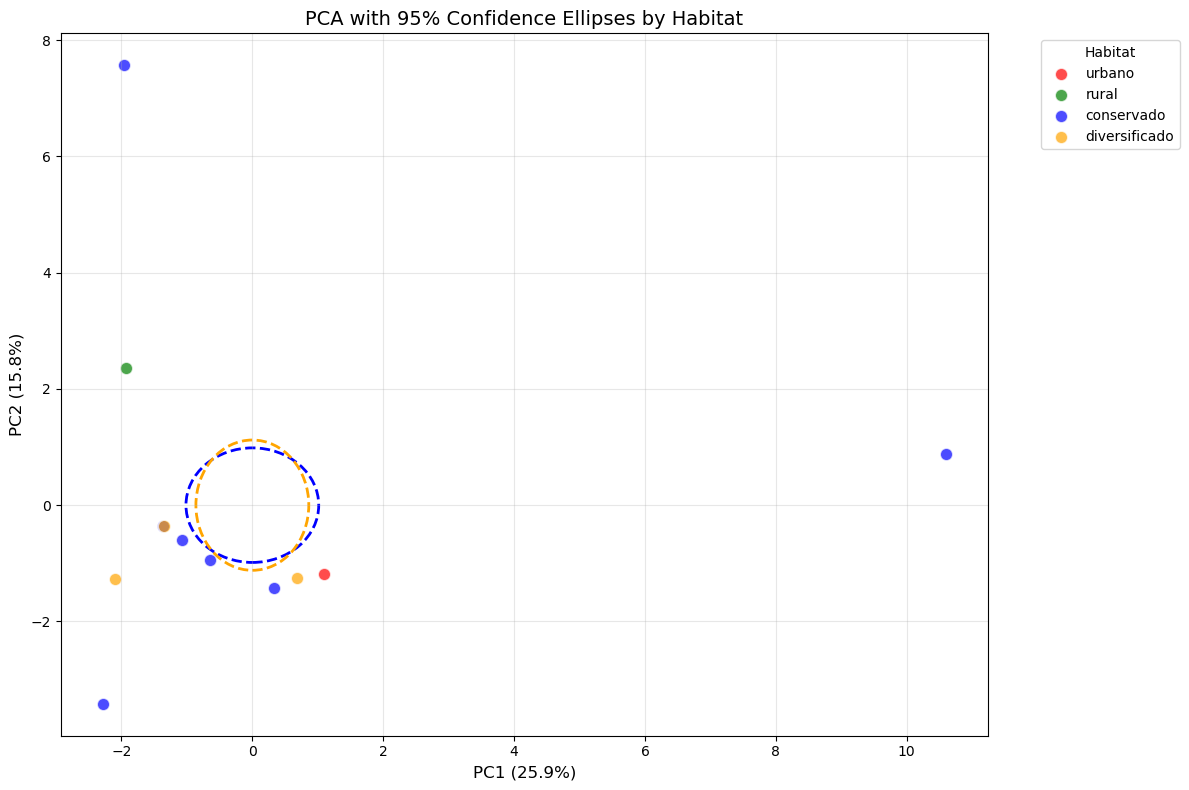

In [11]:
from scipy.stats import chi2

# Define habitat_color_map (match with your actual habitat values)
habitat_color_map = {
    "urbano": "red",
    "rural": "green",
    "conservado": "blue",
    "diversificado": "orange"
}

# Also define species color map if needed
species_color_map = dict(zip(species_unique, sns.color_palette("tab10", len(species_unique))))

def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    """Create confidence ellipse"""
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = plt.gca().transData
    ellipse.set_transform(transf)
    return ax.add_patch(ellipse)

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(12, 8))

# Plot with ellipses for each habitat
for habitat, color in habitat_color_map.items():
    habitat_data = pca_df[pca_df['habitat'] == habitat]
    ax.scatter(habitat_data['PC1'], habitat_data['PC2'], 
              c=color, label=habitat, s=80, alpha=0.7, edgecolors='white')
    
    # Add confidence ellipse (95% confidence)
    if len(habitat_data) > 2:  # Need at least 3 points for ellipse
        confidence_ellipse(habitat_data['PC1'], habitat_data['PC2'], ax,
                          n_std=2.0, edgecolor=color, facecolor='none', 
                          linewidth=2, linestyle='--')

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax.set_title('PCA with 95% Confidence Ellipses by Habitat', fontsize=14)
ax.legend(title='Habitat', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

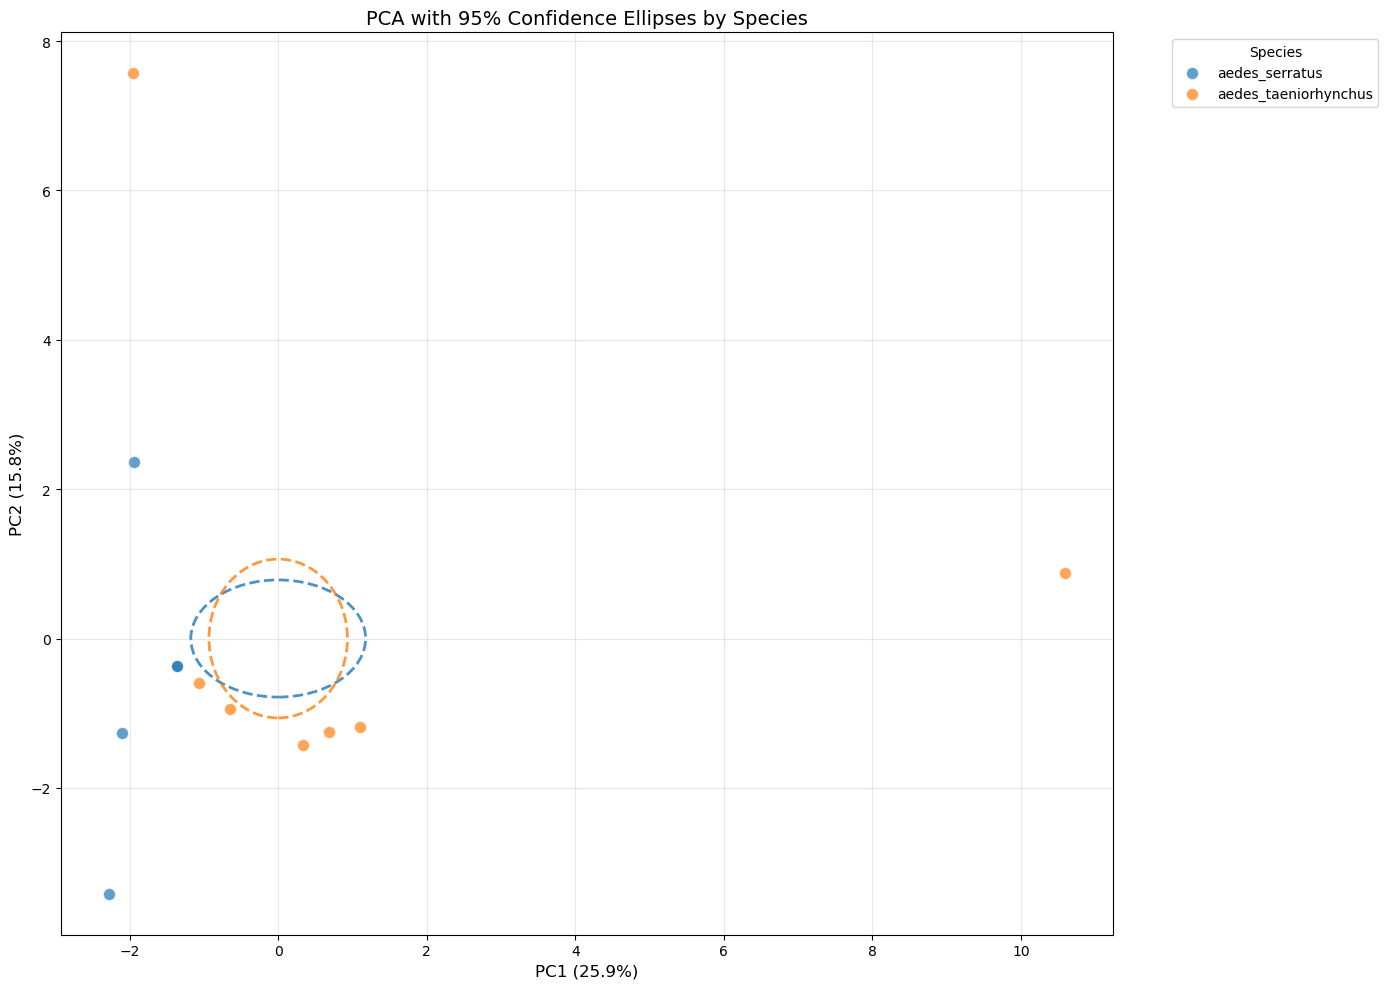

In [12]:
# Plot with ellipses for each species
fig, ax = plt.subplots(figsize=(14, 10))

# Get unique species
unique_species = pca_df['species'].unique()
species_colors = sns.color_palette("tab10", len(unique_species))
species_color_map = dict(zip(unique_species, species_colors))

# Plot with ellipses for each species
for species, color in species_color_map.items():
    species_data = pca_df[pca_df['species'] == species]
    
    if len(species_data) > 0:
        ax.scatter(species_data['PC1'], species_data['PC2'], 
                  c=[color], label=species, s=80, alpha=0.7, edgecolors='white', linewidth=1)
        
        # Add confidence ellipse (95% confidence)
        if len(species_data) >= 3:
            confidence_ellipse(species_data['PC1'], species_data['PC2'], ax,
                              n_std=2.0, edgecolor=color, facecolor='none', 
                              linewidth=2, linestyle='--', alpha=0.8)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax.set_title('PCA with 95% Confidence Ellipses by Species', fontsize=14)
ax.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

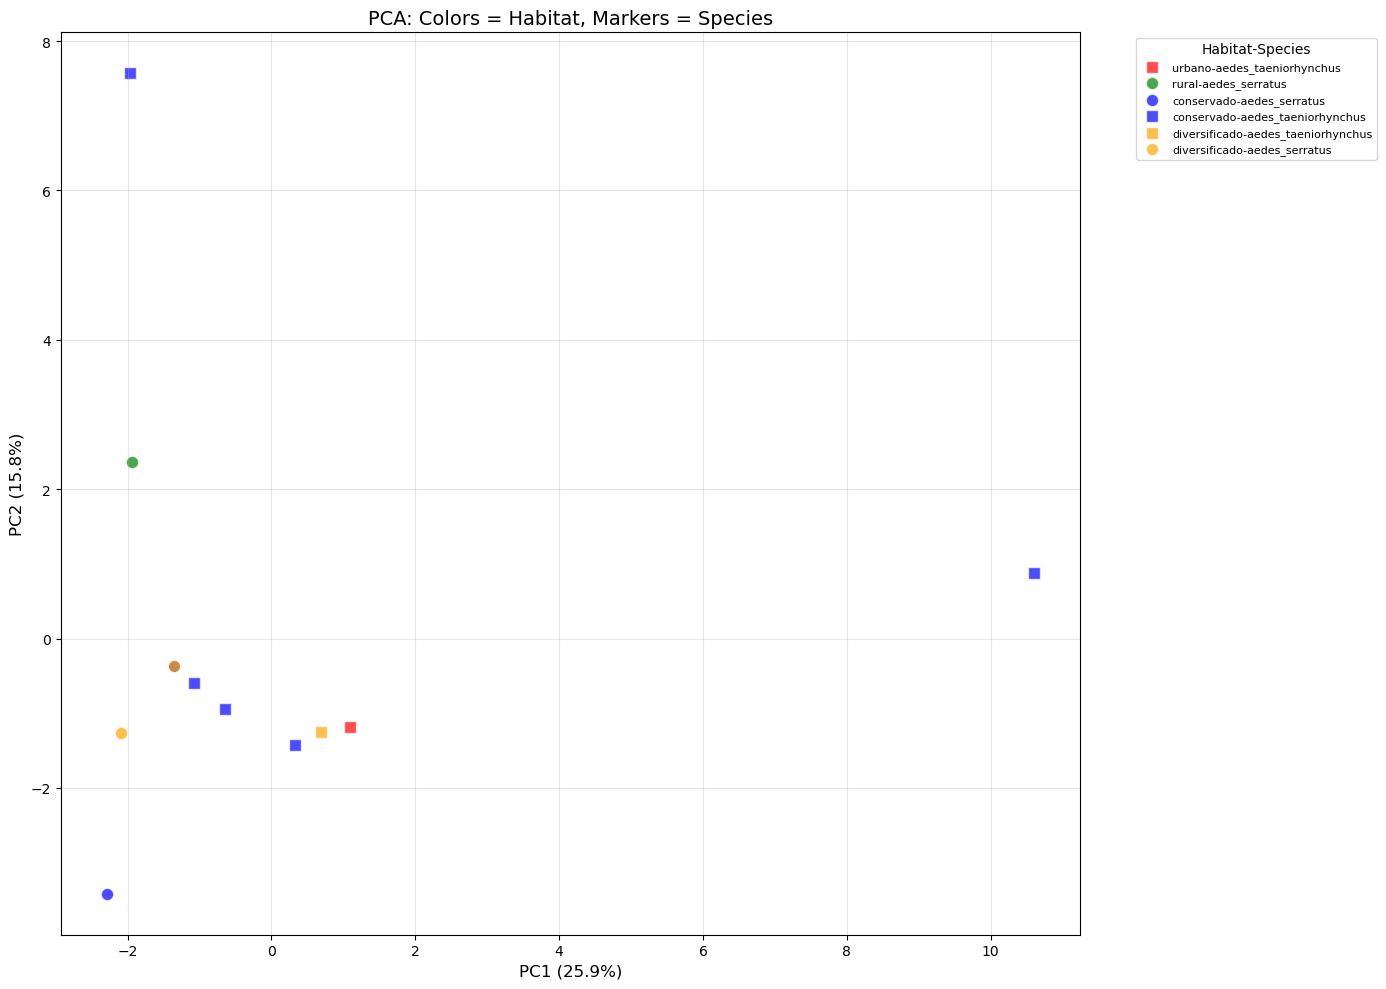

In [13]:
# Combined plot with different markers for species and colors for habitats
fig, ax = plt.subplots(figsize=(14, 10))

# Define marker styles for species
species_markers = {species: marker for species, marker in zip(unique_species, ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h'])}

# Plot with colors for habitats and markers for species
for habitat, color in habitat_color_map.items():
    habitat_data = pca_df[pca_df['habitat'] == habitat]
    
    for species in habitat_data['species'].unique():
        species_data = habitat_data[habitat_data['species'] == species]
        if len(species_data) > 0:
            ax.scatter(species_data['PC1'], species_data['PC2'], 
                      c=color, label=f"{habitat}-{species}", s=80, alpha=0.7, 
                      marker=species_markers.get(species, 'o'), edgecolors='white', linewidth=1)

ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=12)
ax.set_title('PCA: Colors = Habitat, Markers = Species', fontsize=14)
ax.legend(title='Habitat-Species', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Total read depth by sample.

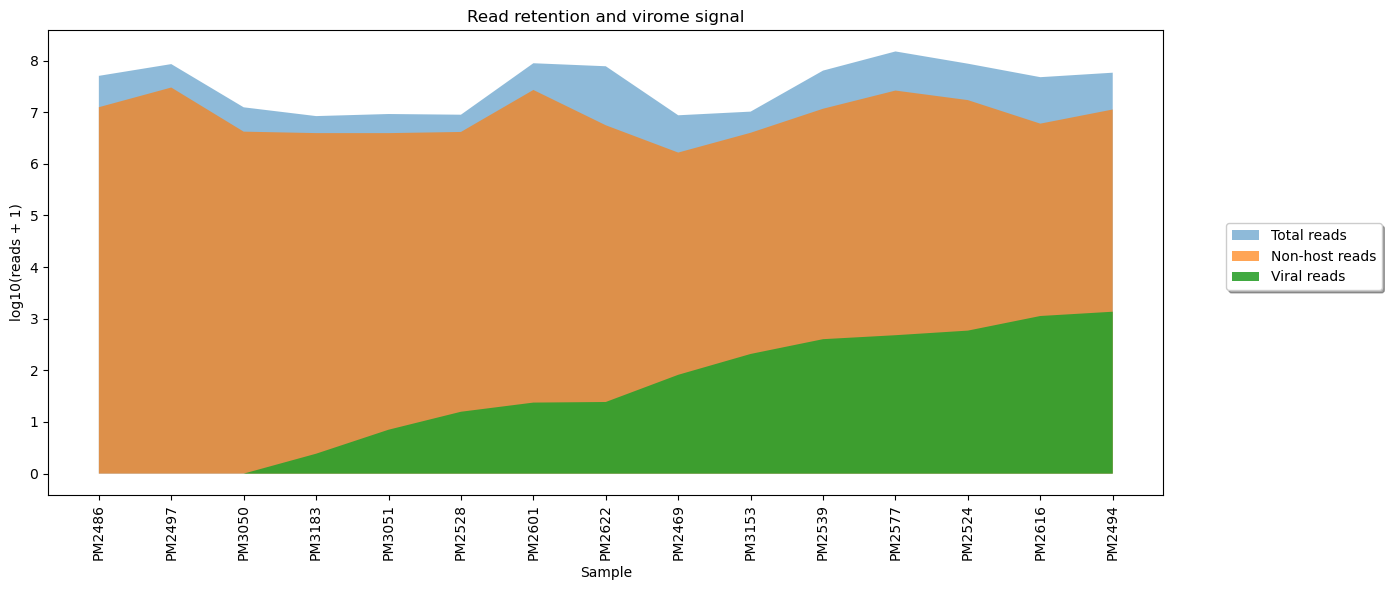

In [14]:
# Read retention and virome signal plot.

# Read definitions:
# Total reads: total number of reads in the sample before any filtering.
# Non-host reads: number of reads that remain after filtering out host reads (mosquito reads in this case).
# Viral reads: number of reads that are classified as viral by CZID.


total_reads = df_metadata.set_index("sample_name")["total_reads"] 

viral_reads = df_final.groupby("sample_name")["nt_rpm"].sum() 

non_host_reads = df_metadata.set_index("sample_name")[ "reads_after_hisat2_host_filtered" ]

df_plot = df_metadata.set_index("sample_name").copy()

# Columnn creation for plotting:
df_plot["viral_reads"] = viral_reads
df_plot["viral_reads"] = df_plot["viral_reads"].fillna(0)
df_plot["non_host_reads"] = df_plot["reads_after_hisat2_host_filtered"]

df_plot["total_log"] = np.log10(df_plot["total_reads"] + 1)
df_plot["non_host_log"] = np.log10(df_plot["non_host_reads"] + 1)
df_plot["viral_log"] = np.log10(df_plot["viral_reads"] + 1)

# Order by total reads.
df_plot = df_plot.sort_values("viral_reads", ascending=True)

# Plotting
plt.figure(figsize=(14, 6))

x = range(len(df_plot))

plt.fill_between(x, df_plot["total_log"], label="Total reads", alpha=0.5)
plt.fill_between(x, df_plot["non_host_log"], label="Non-host reads", alpha=0.7)
plt.fill_between(x, df_plot["viral_log"], label="Viral reads", alpha=0.9)

plt.xticks(x, df_plot.index, rotation=90)
plt.ylabel("log10(reads + 1)")
plt.xlabel("Sample")
plt.title("Read retention and virome signal")

plt.legend(    
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
    )
plt.tight_layout()
plt.show()

 

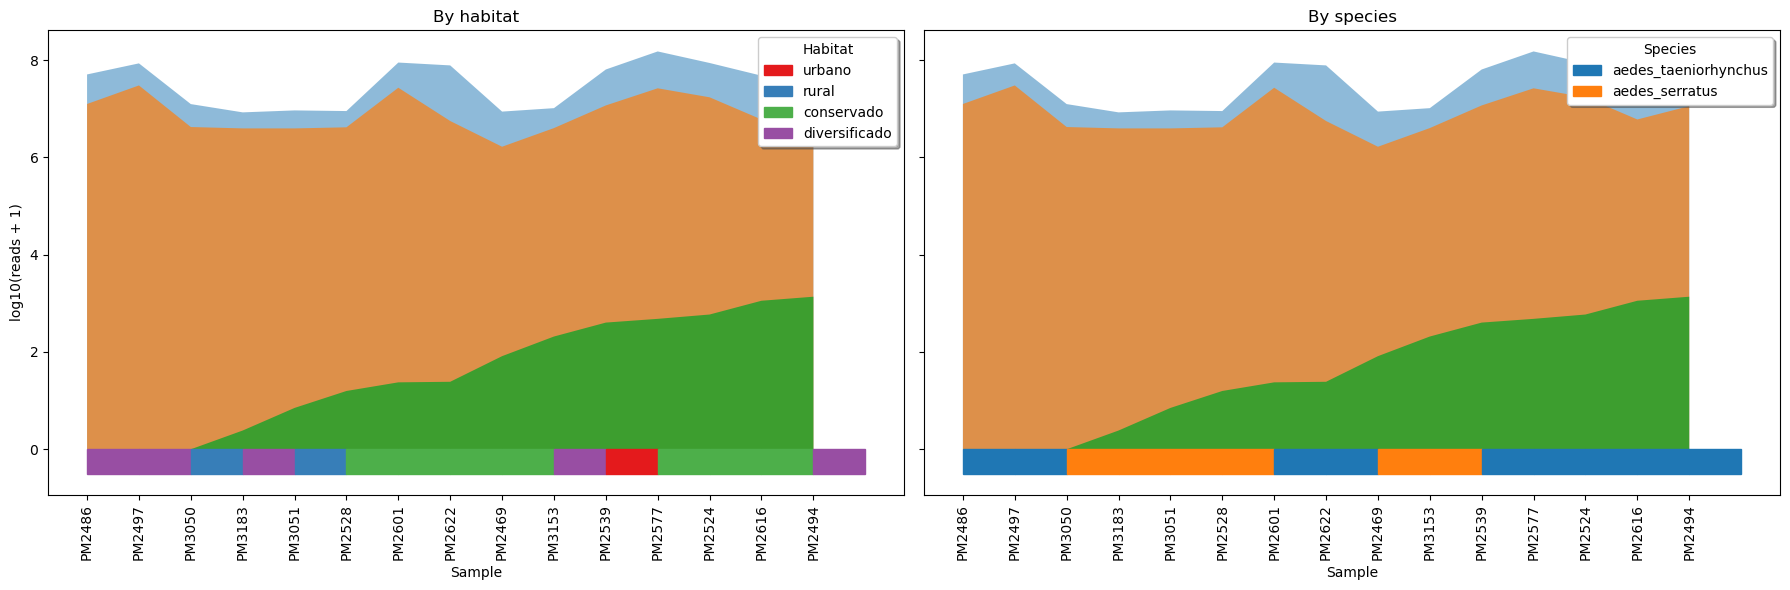

In [16]:
# Order by total reads.
df_plot = df_plot.sort_values("viral_reads", ascending=True)

x = range(len(df_plot))

# Create 2 subplots for habitat and species coloring
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)


# Add metadata
df_plot['habitat'] = df_plot.loc[df_plot.index, 'habitat']
df_plot['species'] = df_plot.loc[df_plot.index, 'species']
df_plot['sample_name'] = df_plot.index


#==============
#   HABITAT
#==============

habitat_colors = df_plot["habitat"].map({
    "urbano": "#e41a1c",
    "rural": "#377eb8",
    "conservado": "#4daf4a",
    "diversificado": "#984ea3"
})

ax1.fill_between(x, df_plot["total_log"], label="Total reads", alpha=0.5)
ax1.fill_between(x, df_plot["non_host_log"], label="Non-host reads", alpha=0.7)
ax1.fill_between(x, df_plot["viral_log"], label="Viral reads", alpha=0.9)


# Color bars by habitat
for i, c in enumerate(habitat_colors):
    ax1.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=c, transform=ax1.transData, clip_on=False)
    )

ax1.set_title("By habitat")
ax1.set_xlabel("Sample")
ax1.set_ylabel("log10(reads + 1)")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot.index, rotation=90)

#==============
#   SPECIES
#==============

species_unique = df_plot["species"].unique()
palette = sns.color_palette("tab10", len(species_unique))
species_dict = dict(zip(species_unique, palette))

colors_species = df_plot["species"].map(species_dict)

ax2.fill_between(x, df_plot["total_log"], label="Total reads", alpha=0.5)
ax2.fill_between(x, df_plot["non_host_log"], label="Non-host reads", alpha=0.7)
ax2.fill_between(x, df_plot["viral_log"], label="Viral reads", alpha=0.9)

# Color bars by species
for i, c in enumerate(colors_species):
    ax2.add_patch(
        plt.Rectangle((i, -0.5), 1, 0.5, color=c, transform=ax2.transData, clip_on=False)
    )

ax2.set_title("By species")
ax2.set_xlabel("Sample")
ax2.set_xticks(x)
ax2.set_xticklabels(df_plot.index, rotation=90)

#==============
#   LEYENDS
#==============


hab_legend = [
    mpatches.Patch(color=color, label=hab)
    for hab, color in {
        "urbano": "#e41a1c",
        "rural": "#377eb8",
        "conservado": "#4daf4a",
        "diversificado": "#984ea3"
    }.items()
]

sp_legend = [
    mpatches.Patch(color=color, label=sp)
    for sp, color in species_dict.items()
]

ax1.legend(
    handles=hab_legend, 
    title="Habitat", 
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
    )

ax2.legend(
    handles=sp_legend, 
    title="Species",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
    )



#==============
#   LAYOUT
#==============

plt.tight_layout()
plt.show()



### Viral family read relative abundance by sample.

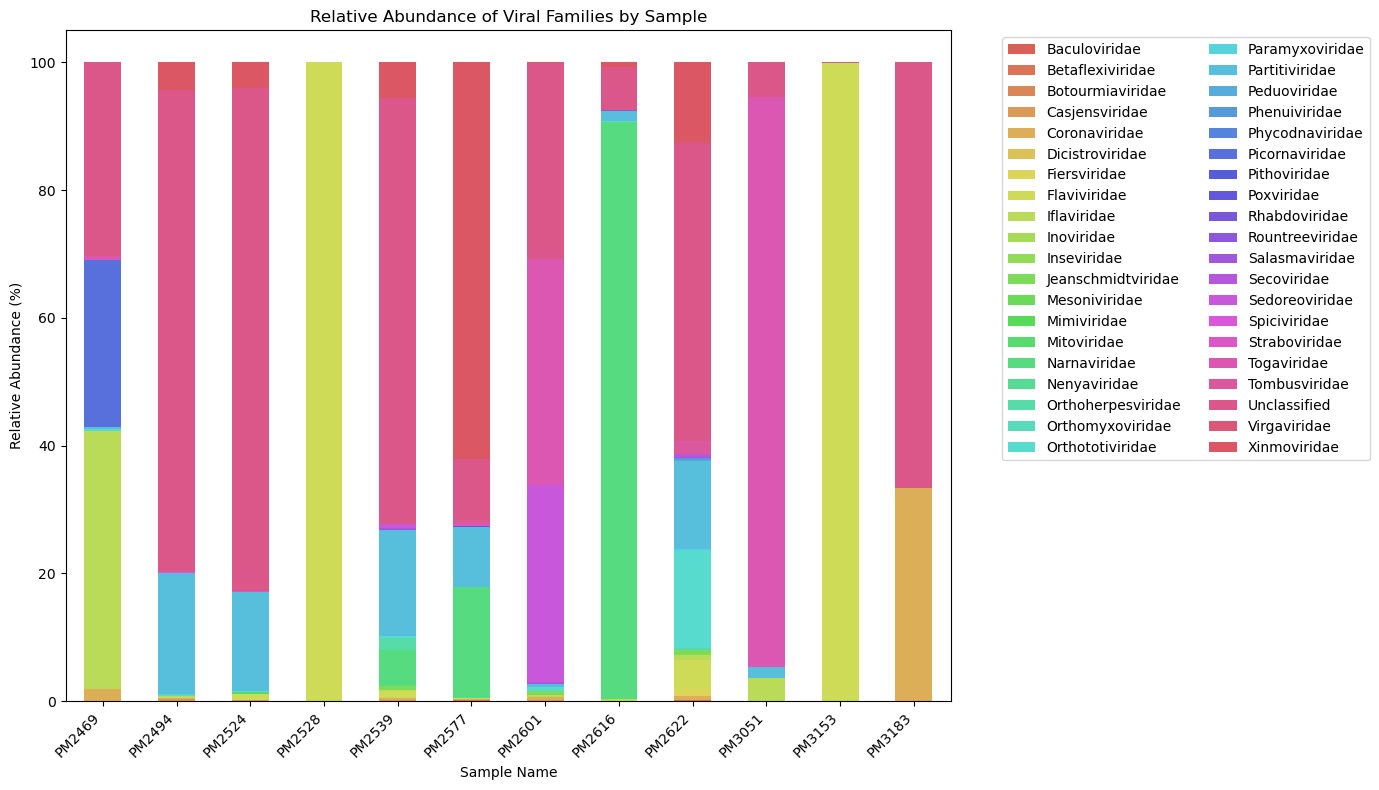

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and prepare data (same as above)
df_family_sum = df_final.groupby(['family', 'sample_name'])['nt_rpm'].sum().reset_index()
df_family_sum['relative_abundance'] = df_family_sum.groupby('sample_name')['nt_rpm'].transform(lambda x: x / x.sum() * 100)
df_family_sum = df_family_sum[df_family_sum['relative_abundance'] > 0.01]
pivot_df = df_family_sum.pivot(index='sample_name', columns='family', values='relative_abundance').fillna(0)

# Generate unique colors
unique_families = pivot_df.columns.tolist()
num_families = len(unique_families)

# Create a color palette with enough distinct colors
if num_families <= 10:
    palette = sns.color_palette("tab10", num_families)
elif num_families <= 20:
    palette = sns.color_palette("tab20", num_families)
elif num_families <= 30:
    palette = sns.color_palette("Set3", num_families)
else:
    # Create a custom palette with many distinct colors
    palette = sns.color_palette("hls", num_families)

color_dict = dict(zip(unique_families, palette))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
pivot_df.plot(kind='bar', stacked=True, color=[color_dict[col] for col in pivot_df.columns], ax=ax)

plt.title('Relative Abundance of Viral Families by Sample')
plt.xlabel('Sample Name')
plt.ylabel('Relative Abundance (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()